In [7]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.data import load_netset
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

In [8]:
# =============================================================================
# Helper Functions (same as embeddings_directed.ipynb)
# =============================================================================

def conformal_quantile(scores, alpha):
    """Mondrian conformal quantile."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def get_node_features(adj, n_components=32):
    """Extract node features via SVD."""
    out_deg = np.array(adj.sum(axis=1)).flatten()
    in_deg = np.array(adj.sum(axis=0)).flatten()
    svd = SVD(n_components=n_components)
    src_emb = svd.fit_transform(adj)
    tgt_emb = svd.embedding_col_
    return out_deg, in_deg, src_emb, tgt_emb

def compute_pair_features(pairs, out_deg, in_deg, src_emb, tgt_emb):
    """Compute directed edge features."""
    u, v = pairs[:, 0], pairs[:, 1]

    vec_u_src, vec_v_tgt = src_emb[u], tgt_emb[v]
    norm_u = np.linalg.norm(vec_u_src, axis=1)
    norm_v = np.linalg.norm(vec_v_tgt, axis=1)
    norm_u[norm_u == 0], norm_v[norm_v == 0] = 1e-9, 1e-9
    sim_fwd = np.sum(vec_u_src * vec_v_tgt, axis=1) / (norm_u * norm_v)

    vec_v_src, vec_u_tgt = src_emb[v], tgt_emb[u]
    norm_v2 = np.linalg.norm(vec_v_src, axis=1)
    norm_u2 = np.linalg.norm(vec_u_tgt, axis=1)
    norm_v2[norm_v2 == 0], norm_u2[norm_u2 == 0] = 1e-9, 1e-9
    sim_rev = np.sum(vec_v_src * vec_u_tgt, axis=1) / (norm_v2 * norm_u2)

    return np.column_stack([out_deg[u], in_deg[v], in_deg[u], out_deg[v], sim_fwd, sim_rev])

# =============================================================================
# Efficiency metrics for prediction sets
# =============================================================================
def set_metrics(y_true, sets):
    """Compute CP metrics: coverage, avg_set_size, retention, decided_acc."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

# =============================================================================
# Risk-coverage curve + AURC
# =============================================================================
def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)
    cum_correct = np.cumsum(correct[order])
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    risks = 1 - cum_correct / np.arange(1, len(y_true) + 1)
    return coverages, risks

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

# =============================================================================
# CP prediction sets from thresholds
# =============================================================================
def cp_sets_from_thresholds(p, t_lower, t_upper):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0:
            s = {0, 1}  # abstain on empty
        sets.append(s)
    return sets

print("Helper functions ready (same as embeddings_directed).")

Helper functions ready (same as embeddings_directed).


In [9]:
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_pipeline(adj, name, alpha=0.10, n_runs=10, n_components=32, msg_ratio=0.7):
    """
    Run directed graph link prediction with conformal prediction.

    Key metrics:
    - AUC, AURC: base classifier quality
    - CP Coverage, Avg Set Size, Retention, Decided Acc: conformal prediction
    """
    print(f"\n{'='*70}")
    print(f"Pipeline: {name.upper()} | {n_runs} runs")
    print(f"{'='*70}")

    n_nodes = adj.shape[0]
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    all_pos_set = set(map(tuple, all_edges))
    print(f"Graph: {n_nodes:,} nodes, {len(all_edges):,} edges")

    run_results = []
    last_run_data = {}
    all_feature_importances = []

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)

        edges = all_edges.copy()
        rng.shuffle(edges)

        # Split: 10% cal, 10% test, 80% train
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)

        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]

        # OGB-style: message (SVD) + supervision (classifier)
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]
        E_sup = E_train_all[train_idx[n_msg:]]

        # Build representation graph from MESSAGE edges only
        adj_msg = sp.csr_matrix((np.ones(len(E_msg)), (E_msg[:,0], E_msg[:,1])), shape=(n_nodes, n_nodes))
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        out_deg, in_deg, src_emb, tgt_emb = get_node_features(adj_msg, n_components)
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

        def make_dataset(pos_edges, exclude_set, all_pos_set):
            neg_edges = set()
            while len(neg_edges) < len(pos_edges):
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in exclude_set and (u, v) not in all_pos_set:
                    neg_edges.add((u, v))
            neg_edges = np.array(list(neg_edges))

            X_pos = compute_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            pairs = np.vstack([pos_edges, neg_edges])
            return X, y, pairs

        X_train, y_train, _ = make_dataset(E_sup, known_edges_set, all_pos_set)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, _ = make_dataset(E_cal, cal_exclude, all_pos_set)
        X_test, y_test, test_pairs = make_dataset(E_test, known_edges_set, all_pos_set)

        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # Store feature importances
        all_feature_importances.append(clf.feature_importances_)

        # ============================================================
        # CP thresholds on full calibration set
        # ============================================================
        scores_pos = 1 - p_cal[y_cal == 1]
        scores_neg = p_cal[y_cal == 0]
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        t_lower, t_upper = q0, 1 - q1

        # ====== Evaluate on TEST ======
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        cp_m = set_metrics(y_test, cp_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_cov, rc_risk = risk_coverage_curve(y_test, p_test)
        aurc_val = aurc(rc_cov, rc_risk)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_val,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
        })

        last_run_data = {
            'y_test': y_test, 'p_test': p_test, 'cp_sets_test': cp_sets_test,
            't_lower': t_lower, 't_upper': t_upper,
            'auc': auc, 'aurc': aurc_val, 'rc_cov': rc_cov, 'rc_risk': rc_risk,
            'feature_importances': clf.feature_importances_,
        }

        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | AURC={aurc_val:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    # Compute mean and std of feature importances across runs
    feature_importances_mean = np.mean(all_feature_importances, axis=0)
    feature_importances_std = np.std(all_feature_importances, axis=0)

    print(f"\n{'='*60}")
    print(f"RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"  AUC             : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")
    print(f"\n--- CP (alpha={alpha}) ---")
    print(f"  Coverage        : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size    : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention       : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Acc     : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")

    # Visualization (3 plots)
    y_test, p_test = last_run_data['y_test'], last_run_data['p_test']
    t_lower, t_upper = last_run_data['t_lower'], last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_cov, rc_risk = last_run_data['rc_cov'], last_run_data['rc_risk']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{name.upper()} Results', fontsize=14, fontweight='bold')

    # Plot 1: Risk-Coverage curve
    ax = axes[0]
    ax.plot(rc_cov, rc_risk, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    ax.fill_between(rc_cov, rc_risk, alpha=0.3, color='purple')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Risk (1 - Accuracy)')
    ax.set_title('Risk-Coverage Curve'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 2: Probability distributions
    ax = axes[1]
    ax.hist(p_test[y_test == 0], bins=30, alpha=0.5, color='red', label='No Edge', density=True)
    ax.hist(p_test[y_test == 1], bins=30, alpha=0.5, color='blue', label='Edge', density=True)
    ax.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    ax.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title('CP Thresholds'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Set sizes
    ax = axes[2]
    sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(sizes, return_counts=True)
    colors_bar = ['green' if u == 1 else 'orange' for u in unique]
    ax.bar(unique, counts, color=colors_bar, alpha=0.7)
    ax.set_xlabel('Set Size'); ax.set_ylabel('Count')
    ax.set_title(f'Set Size Distribution (Ret={means["CP Retention"]:.1%})')
    ax.set_xticks(unique); ax.set_xticklabels(['Decided' if u == 1 else 'Abstain' for u in unique])
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return {
        'name': name, 
        'df': df, 
        'means': df.mean().to_dict(), 
        'last_run': last_run_data,
        'feature_importances_mean': feature_importances_mean,
        'feature_importances_std': feature_importances_std,
    }

print("Pipeline ready (same as embeddings_directed).")

Pipeline ready (same as embeddings_directed).


In [10]:
def load_and_prepare(dataset_name):
    """Load dataset - use full graph."""
    data = load_netset(dataset_name)
    adj = data.adjacency
    names = data.names if hasattr(data, 'names') else None
    
    # Ensure sparse CSR format
    if not sp.isspmatrix_csr(adj):
        adj = sp.csr_matrix(adj)
    
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    print(f"Loaded {dataset_name}: {adj.shape[0]:,} nodes, {adj.nnz:,} edges")
    return adj, names

In [11]:
# Configuration
DATASETS = ['wikivitals', 'wikischools', 'wikihumans', 'wikivitals-fr', 'mathworld']

N_RUNS = 10
ALPHA = 0.10
N_COMPONENTS = 32

all_results = []

Parsing files...
Done.
Loaded wikivitals: 10,011 nodes, 823,619 edges

Pipeline: WIKIVITALS | 10 runs
Graph: 10,011 nodes, 823,619 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.899, Ret=0.972, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.899, Ret=0.970, Acc=0.896]


...

Run 8/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.900, Ret=0.967, Acc=0.897]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9529 | AURC=0.0311 | CP[Cov=0.900, Ret=0.973, Acc=0.897]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.899, Ret=0.973, Acc=0.896]

RESULTS (WIKIVITALS)
  AUC             : 0.9525 +/- 0.0004
  AURC            : 0.0314 +/- 0.0003

--- CP (alpha=0.1) ---
  Coverage        : 0.8997 +/- 0.0011  (target: 0.90)
  Avg Set Size    : 1.0287 +/- 0.0024
  Retention       : 0.9713 +/- 0.0024
  Decided Acc     : 0.8967 +/- 0.0010


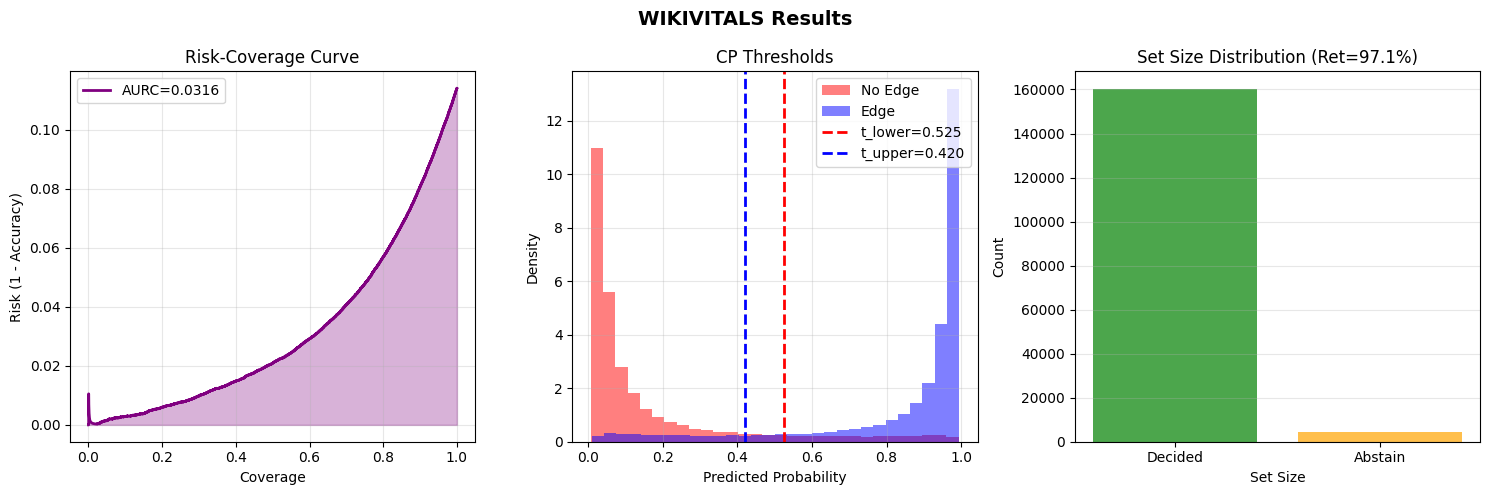

In [12]:
# Run WikiVitals
adj, names = load_and_prepare('wikivitals')
result = run_pipeline(adj, 'WikiVitals', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikischools: 4,403 nodes, 112,728 edges

Pipeline: WIKISCHOOLS | 10 runs
Graph: 4,403 nodes, 112,728 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9326 | AURC=0.0467 | CP[Cov=0.902, Ret=0.903, Acc=0.891]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9367 | AURC=0.0435 | CP[Cov=0.903, Ret=0.913, Acc=0.893]


...

Run 8/10: AUC=0.9363 | AURC=0.0438 | CP[Cov=0.902, Ret=0.910, Acc=0.892]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9341 | AURC=0.0452 | CP[Cov=0.901, Ret=0.910, Acc=0.891]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9319 | AURC=0.0473 | CP[Cov=0.900, Ret=0.911, Acc=0.890]

RESULTS (WIKISCHOOLS)
  AUC             : 0.9343 +/- 0.0020
  AURC            : 0.0455 +/- 0.0016

--- CP (alpha=0.1) ---
  Coverage        : 0.9009 +/- 0.0021  (target: 0.90)
  Avg Set Size    : 1.0893 +/- 0.0037
  Retention       : 0.9107 +/- 0.0037
  Decided Acc     : 0.8911 +/- 0.0023


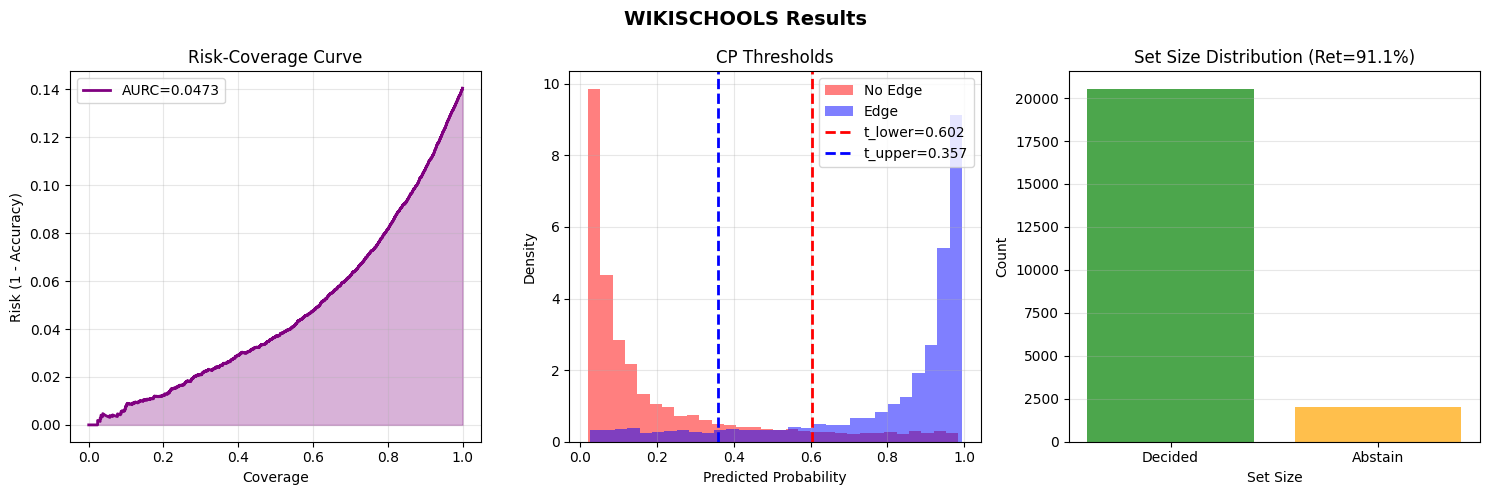

In [13]:
# Run WikiSchools
adj, names = load_and_prepare('wikischools')
result = run_pipeline(adj, 'WikiSchools', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikihumans: 1,014,428 nodes, 3,919,083 edges

Pipeline: WIKIHUMANS | 10 runs
Graph: 1,014,428 nodes, 3,919,083 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9452 | AURC=0.0318 | CP[Cov=0.900, Ret=0.958, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9457 | AURC=0.0314 | CP[Cov=0.900, Ret=0.963, Acc=0.896]


...

Run 8/10: AUC=0.9457 | AURC=0.0317 | CP[Cov=0.900, Ret=0.962, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9461 | AURC=0.0312 | CP[Cov=0.901, Ret=0.960, Acc=0.897]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9456 | AURC=0.0316 | CP[Cov=0.900, Ret=0.962, Acc=0.896]

RESULTS (WIKIHUMANS)
  AUC             : 0.9456 +/- 0.0004
  AURC            : 0.0316 +/- 0.0002

--- CP (alpha=0.1) ---
  Coverage        : 0.9002 +/- 0.0004  (target: 0.90)
  Avg Set Size    : 1.0392 +/- 0.0018
  Retention       : 0.9608 +/- 0.0018
  Decided Acc     : 0.8961 +/- 0.0004


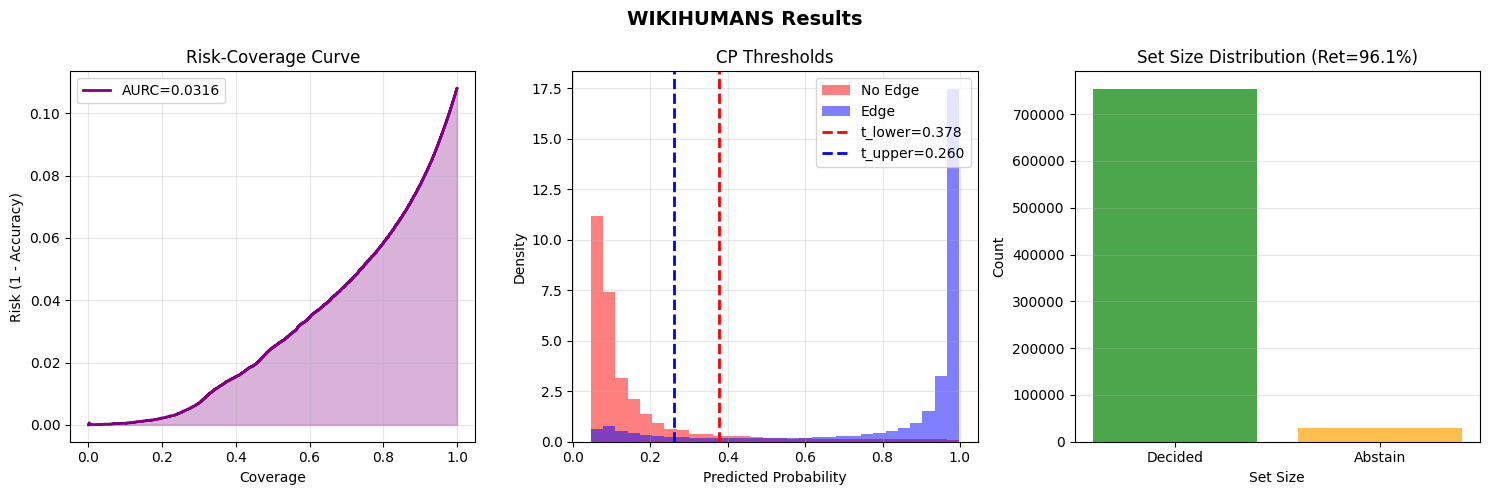

In [14]:
# Run WikiHumans (full graph)
adj, names = load_and_prepare('wikihumans')
result = run_pipeline(adj, 'WikiHumans', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikivitals-fr: 9,945 nodes, 558,205 edges

Pipeline: WIKIVITALS-FR | 10 runs
Graph: 9,945 nodes, 558,205 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9528 | AURC=0.0312 | CP[Cov=0.900, Ret=0.969, Acc=0.897]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9534 | AURC=0.0306 | CP[Cov=0.899, Ret=0.971, Acc=0.896]


...

Run 8/10: AUC=0.9532 | AURC=0.0308 | CP[Cov=0.901, Ret=0.968, Acc=0.898]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9533 | AURC=0.0308 | CP[Cov=0.901, Ret=0.970, Acc=0.898]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9529 | AURC=0.0308 | CP[Cov=0.899, Ret=0.970, Acc=0.896]

RESULTS (WIKIVITALS-FR)
  AUC             : 0.9531 +/- 0.0004
  AURC            : 0.0310 +/- 0.0003

--- CP (alpha=0.1) ---
  Coverage        : 0.8997 +/- 0.0018  (target: 0.90)
  Avg Set Size    : 1.0289 +/- 0.0025
  Retention       : 0.9711 +/- 0.0025
  Decided Acc     : 0.8968 +/- 0.0016


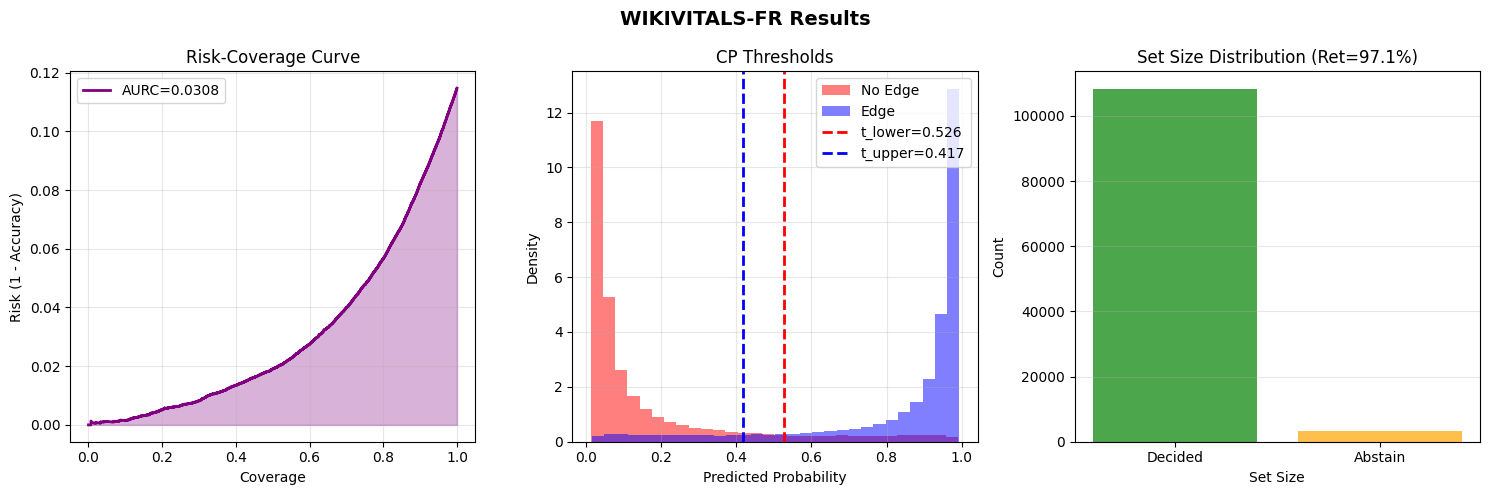

In [15]:
# Run WikiVitals (fr) - full graph
adj, names = load_and_prepare('wikivitals-fr')
result = run_pipeline(adj, 'WikiVitals-FR', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)


Parsing files...
Done.
Loaded mathworld: 12,362 nodes, 49,068 edges

Pipeline: MATHWORLD | 10 runs
Graph: 12,362 nodes, 49,068 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9193 | AURC=0.0509 | CP[Cov=0.901, Ret=0.865, Acc=0.885]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9110 | AURC=0.0552 | CP[Cov=0.896, Ret=0.849, Acc=0.878]


...

Run 8/10: AUC=0.9118 | AURC=0.0551 | CP[Cov=0.899, Ret=0.834, Acc=0.878]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9123 | AURC=0.0541 | CP[Cov=0.897, Ret=0.854, Acc=0.879]


C:\Users\longv\AppData\Local\Temp\ipykernel_2284\2562428354.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9108 | AURC=0.0559 | CP[Cov=0.894, Ret=0.861, Acc=0.877]

RESULTS (MATHWORLD)
  AUC             : 0.9124 +/- 0.0032
  AURC            : 0.0549 +/- 0.0024

--- CP (alpha=0.1) ---
  Coverage        : 0.8983 +/- 0.0028  (target: 0.90)
  Avg Set Size    : 1.1546 +/- 0.0140
  Retention       : 0.8454 +/- 0.0140
  Decided Acc     : 0.8797 +/- 0.0027


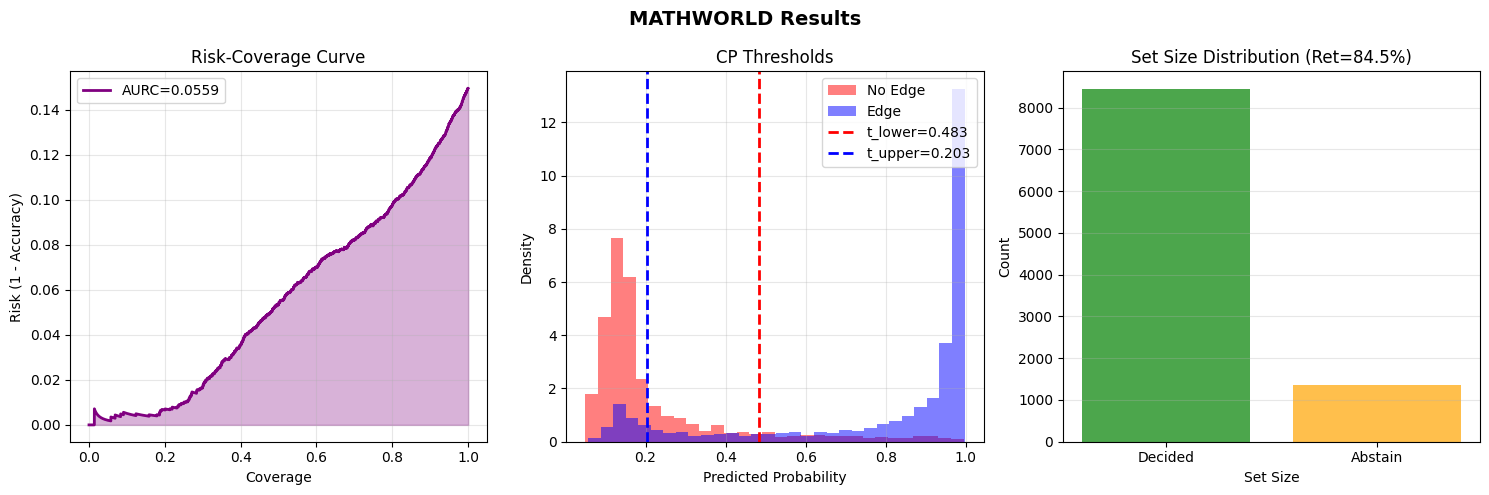

In [16]:
# Run MathWorld - full graph
adj, names = load_and_prepare('mathworld')
result = run_pipeline(adj, 'MathWorld', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

In [17]:
# Comparison Summary
print("\n" + "="*80)
print("COMPARISON ACROSS ALL DATASETS")
print("="*80)

comparison_data = []
for r in all_results:
    row = {'Dataset': r['name']}
    row.update(r['means'])
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n--- Key Findings ---")
print(f"Best AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Dataset']} ({comparison_df['AUC'].max():.4f})")
print(f"Best AURC: {comparison_df.loc[comparison_df['AURC'].idxmin(), 'Dataset']} ({comparison_df['AURC'].min():.4f})")
print(f"Highest CP Retention: {comparison_df.loc[comparison_df['CP Retention'].idxmax(), 'Dataset']} ({comparison_df['CP Retention'].max():.4f})")


COMPARISON ACROSS ALL DATASETS
      Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc
   WikiVitals 0.952532 0.031363     0.899694         1.028727      0.971273        0.896729
  WikiSchools 0.934264 0.045470     0.900852         1.089314      0.910686        0.891128
   WikiHumans 0.945643 0.031553     0.900161         1.039226      0.960774        0.896085
WikiVitals-FR 0.953080 0.030956     0.899747         1.028931      0.971069        0.896763
    MathWorld 0.912354 0.054910     0.898267         1.154576      0.845424        0.879665

--- Key Findings ---
Best AUC: WikiVitals-FR (0.9531)
Best AURC: WikiVitals-FR (0.0310)
Highest CP Retention: WikiVitals (0.9713)


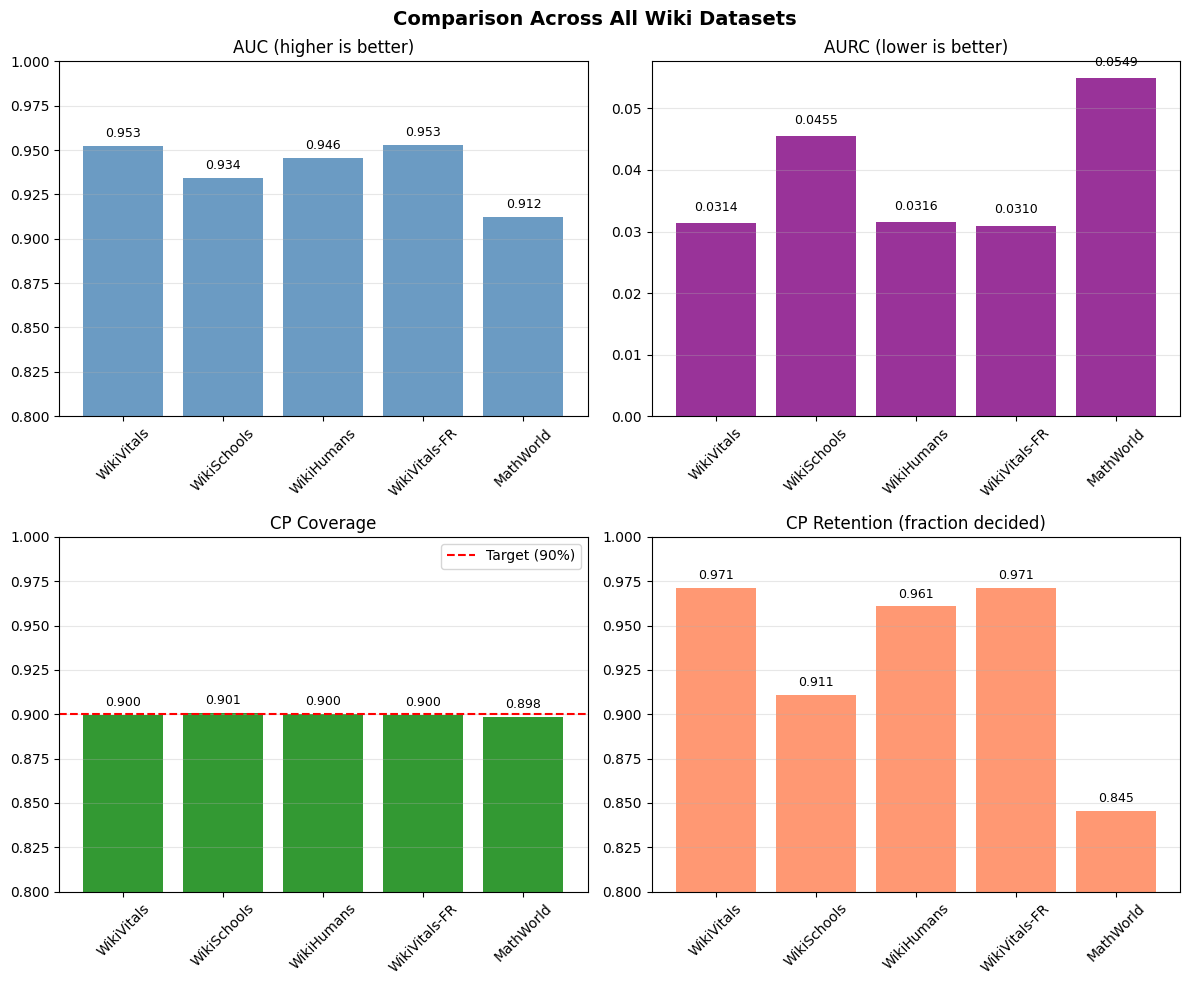

In [18]:
# Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = [r['name'] for r in all_results]

# Plot 1: AUC
ax = axes[0, 0]
values = [r['means']['AUC'] for r in all_results]
bars = ax.bar(datasets, values, color='steelblue', alpha=0.8)
ax.set_title('AUC (higher is better)')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Plot 2: AURC
ax = axes[0, 1]
values = [r['means']['AURC'] for r in all_results]
bars = ax.bar(datasets, values, color='purple', alpha=0.8)
ax.set_title('AURC (lower is better)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Plot 3: CP Coverage vs Target
ax = axes[1, 0]
values = [r['means']['CP Coverage'] for r in all_results]
bars = ax.bar(datasets, values, color='green', alpha=0.8)
ax.axhline(0.9, color='red', linestyle='--', label='Target (90%)')
ax.set_title('CP Coverage')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 4: CP Retention
ax = axes[1, 1]
values = [r['means']['CP Retention'] for r in all_results]
bars = ax.bar(datasets, values, color='coral', alpha=0.8)
ax.set_title('CP Retention (fraction decided)')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Comparison Across All Wiki Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE ANALYSIS
Features: ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']


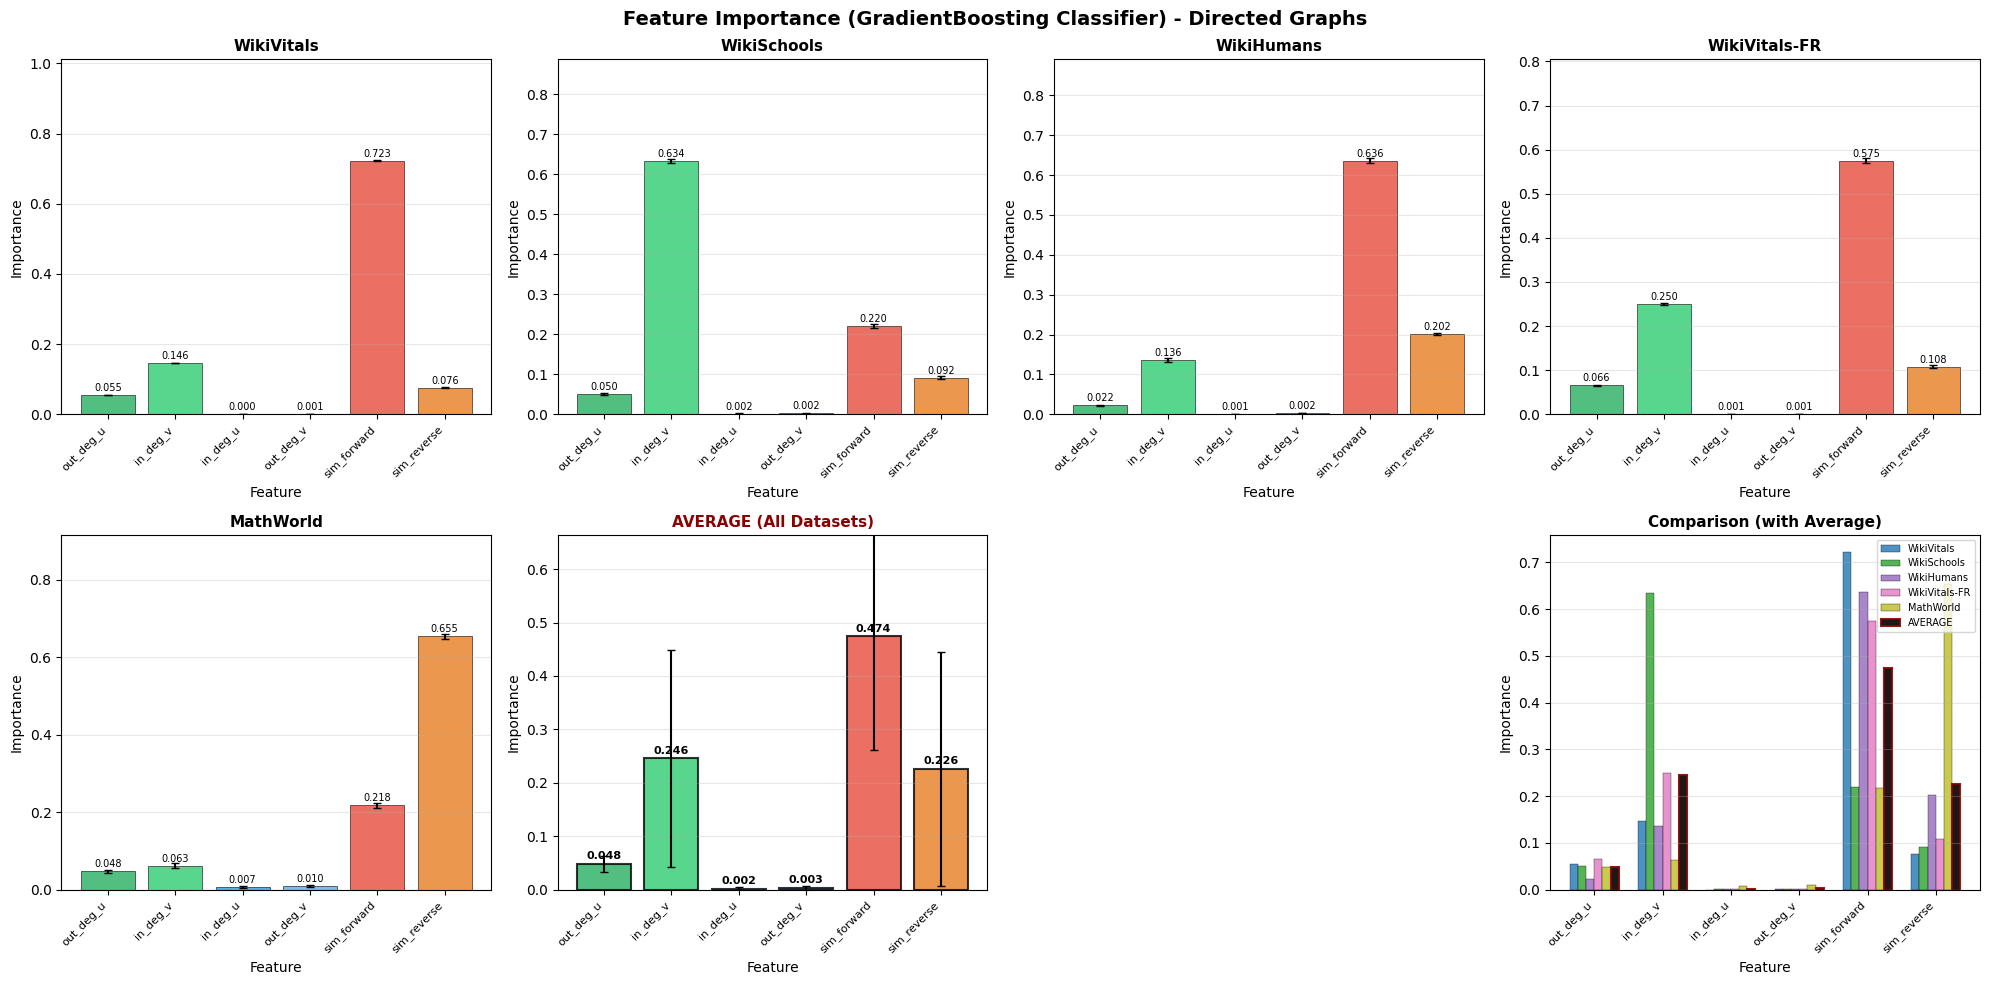


--- Feature Importance Summary ---
Dataset         |    out_deg_u |     in_deg_v |     in_deg_u |    out_deg_v |  sim_forward |  sim_reverse
---------------------------------------------------------------------------------------------------------
WikiVitals      |       0.0548 |       0.1460 |       0.0001 |       0.0006 |       0.7226 |       0.0759
WikiSchools     |       0.0503 |       0.6336 |       0.0019 |       0.0022 |       0.2203 |       0.0917
WikiHumans      |       0.0225 |       0.1362 |       0.0012 |       0.0024 |       0.6360 |       0.2017
WikiVitals-FR   |       0.0661 |       0.2497 |       0.0007 |       0.0007 |       0.5749 |       0.1078
MathWorld       |       0.0484 |       0.0626 |       0.0070 |       0.0097 |       0.2178 |       0.6545
---------------------------------------------------------------------------------------------------------
AVERAGE         |       0.0484 |       0.2456 |       0.0022 |       0.0031 |       0.4743 |       0.2263
(std)     

In [19]:
# =============================================================================
# Feature Importance Analysis (6 Directed Features)
# =============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)
print(f"Features: {FEATURE_NAMES}")

# Compute average feature importance across all datasets
all_importances = np.array([r['feature_importances_mean'] for r in all_results])
avg_importance = np.mean(all_importances, axis=0)
std_importance = np.std(all_importances, axis=0)

# Create figure with subplots for each dataset + average + comparison
n_datasets = len(all_results)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Colors for 6 features: degree features (greens/blues) and similarity features (reds/oranges)
colors = ['#27ae60', '#2ecc71', '#3498db', '#5dade2', '#e74c3c', '#e67e22']
# out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse

# Individual dataset plots
for idx, r in enumerate(all_results):
    ax = axes[idx]
    importances = r['feature_importances_mean']
    stds = r['feature_importances_std']
    
    x = np.arange(len(FEATURE_NAMES))
    bars = ax.bar(x, importances, yerr=stds, color=colors, alpha=0.8, capsize=3, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Feature', fontsize=10)
    ax.set_ylabel('Importance', fontsize=10)
    ax.set_title(f'{r["name"]}', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_NAMES, fontsize=8, rotation=45, ha='right')
    ax.set_ylim(0, max(importances) * 1.4)
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, importances):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

# Average feature importance plot
ax = axes[n_datasets]
x = np.arange(len(FEATURE_NAMES))
bars = ax.bar(x, avg_importance, yerr=std_importance, color=colors, alpha=0.8, capsize=3, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('Importance', fontsize=10)
ax.set_title('AVERAGE (All Datasets)', fontsize=11, fontweight='bold', color='darkred')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, fontsize=8, rotation=45, ha='right')
ax.set_ylim(0, max(avg_importance) * 1.4)
ax.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, avg_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Combined comparison plot (last subplot)
ax = axes[-1]
x = np.arange(len(FEATURE_NAMES))
width = 0.12
offsets = np.linspace(-width * n_datasets/2, width * n_datasets/2, n_datasets + 1)

dataset_colors = plt.cm.tab10(np.linspace(0, 1, n_datasets + 1))

for idx, r in enumerate(all_results):
    importances = r['feature_importances_mean']
    bars = ax.bar(x + offsets[idx], importances, width, 
                  label=r['name'], color=dataset_colors[idx], alpha=0.8, edgecolor='black', linewidth=0.3)

# Add average to comparison
bars = ax.bar(x + offsets[-1], avg_importance, width, 
              label='AVERAGE', color='black', alpha=0.9, edgecolor='darkred', linewidth=1.5)

ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('Importance', fontsize=10)
ax.set_title('Comparison (with Average)', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, fontsize=8, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=7)
ax.grid(alpha=0.3, axis='y')

# Hide unused subplot
axes[-2].axis('off')

plt.suptitle('Feature Importance (GradientBoosting Classifier) - Directed Graphs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print feature importance table
print("\n--- Feature Importance Summary ---")
print(f"{'Dataset':<15} | " + " | ".join([f'{f:>12}' for f in FEATURE_NAMES]))
print("-" * 105)
for r in all_results:
    vals = " | ".join([f'{r["feature_importances_mean"][i]:>12.4f}' for i in range(len(FEATURE_NAMES))])
    print(f"{r['name']:<15} | {vals}")
print("-" * 105)
avg_vals = " | ".join([f'{avg_importance[i]:>12.4f}' for i in range(len(FEATURE_NAMES))])
print(f"{'AVERAGE':<15} | {avg_vals}")
std_vals = " | ".join([f'{std_importance[i]:>12.4f}' for i in range(len(FEATURE_NAMES))])
print(f"{'(std)':<15} | {std_vals}")

# Additional analysis: group features by type
print("\n--- Feature Groups Analysis ---")
print("Degree features: out_deg_u, in_deg_v, in_deg_u, out_deg_v")
print("Similarity features: sim_forward, sim_reverse")
print()
for r in all_results:
    deg_importance = sum(r['feature_importances_mean'][:4])
    sim_importance = sum(r['feature_importances_mean'][4:])
    print(f"{r['name']:<15}: Degree={deg_importance:.3f} ({deg_importance*100:.1f}%), Similarity={sim_importance:.3f} ({sim_importance*100:.1f}%)")

# Average group analysis
avg_deg = sum(avg_importance[:4])
avg_sim = sum(avg_importance[4:])
print("-" * 60)
print(f"{'AVERAGE':<15}: Degree={avg_deg:.3f} ({avg_deg*100:.1f}%), Similarity={avg_sim:.3f} ({avg_sim*100:.1f}%)")

# Rank features by average importance
print("\n--- Feature Ranking (by average importance) ---")
ranked_indices = np.argsort(avg_importance)[::-1]
for rank, idx in enumerate(ranked_indices, 1):
    print(f"  {rank}. {FEATURE_NAMES[idx]:<15}: {avg_importance[idx]:.4f} +/- {std_importance[idx]:.4f}")

In [22]:
# Summary Table
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_cols = ['Dataset', 'AUC', 'AURC', 'CP Coverage', 'CP Avg Set Size', 'CP Retention', 'CP Decided Acc']
print(comparison_df[summary_cols].to_string(index=False))




FINAL SUMMARY TABLE
      Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc
   WikiVitals 0.952532 0.031363     0.899694         1.028727      0.971273        0.896729
  WikiSchools 0.934264 0.045470     0.900852         1.089314      0.910686        0.891128
   WikiHumans 0.945643 0.031553     0.900161         1.039226      0.960774        0.896085
WikiVitals-FR 0.953080 0.030956     0.899747         1.028931      0.971069        0.896763
    MathWorld 0.912354 0.054910     0.898267         1.154576      0.845424        0.879665


In [21]:
# Display final table
display(comparison_df.round(4))

,Dataset,AUC,AURC,CP Coverage,CP Avg Set Size,CP Retention,CP Decided Acc
0,WikiVitals,0.9525,0.0314,0.8997,1.0287,0.9713,0.8967
1,WikiSchools,0.9343,0.0455,0.9009,1.0893,0.9107,0.8911
2,WikiHumans,0.9456,0.0316,0.9002,1.0392,0.9608,0.8961
3,WikiVitals-FR,0.9531,0.0310,0.8997,1.0289,0.9711,0.8968
4,MathWorld,0.9124,0.0549,0.8983,1.1546,0.8454,0.8797
